01_inventario
02_frescura cero  de la base de abril join abril y marzo  
03_cliente con la base regular  
04_base regular  lo que queda

In [ ]:
punto de equilibrio


In [57]:
spark.stop()

In [1]:
import sys 
sys.path.append('C:/Users/DATA/Documents/datos/01_script/inicio/funciones')
from funciones import *
from funciones_spark import *
from variables_inicio import *
from utils_sql import *

spark = SparkSession.builder \
    .appName("SparkExample") \
    .master("local[*]") \
    .config('spark.driver.extraClassPath', 'C:/spark/jars/mssql-jdbc-13.2.1.jre11.jar') \
    .config('spark.executor.extraClassPath', 'C:/spark/jars/mssql-jdbc-13.2.1.jre11.jar') \
    .config('spark.executor.memory', '8g') \
    .config('spark.driver.memory', '8g') \
    .getOrCreate()

### armar lista credicash

In [7]:
   
ls_una_vez=[]
ls_casilla=[]
ls_ocupado=[]
tb_gestiones='alfcc_gestion'
tb_cliente='alfcc_clientes'
tb_tipolofia='ALFcc_tipificaciones'
fecha_mes_base='2026-05-01'
get_base=since_base_maestra_alfcc
tlista_generada='borrar_credicash_01'
name_campana='alfcc'
app_campana=17
    # lista_generada_valentina_actual(spark,fecha_mes_base,ls_una_vez,ls_casilla,ls_ocupado,tlista_generada,tb_tipolofia,tb_gestiones,tb_cliente,get_base,name_campana,app_campana)   


In [8]:
ventas_valentina_mes(name_campana,fecha_mes_base,user_valentina,pwd_valentina,server_valentina,port_mysql,db_valentina)
df_venta=cargar_archivo_csv(spark,'tmp_vent.csv',';',True)


In [9]:


df_vicidial=since_valentina_actual(spark,fecha_mes_base,tb_tipolofia,tb_gestiones,name_campana,app_campana)
df_base_vigente = get_base(spark,fecha_mes_base)
df_base_vigente = df_base_vigente.withColumn(
        "dni_cliente",
        F.right(
            F.concat(F.lit("00000000"), F.col("dni_cliente")),
            F.lit(8)
        )
    )

df_tnumeric=since_tnumeros_valentina(spark,tb_cliente,fecha_mes_base)
df_tnumeric = df_tnumeric.withColumn(
        "dni_cliente",
        F.right(
            F.concat(F.lit("00000000"), F.col("dni_cliente")),
            F.lit(8)
        )
    )


In [10]:

    df_mejor_telf = df_vicidial.filter(
        (F.col("duracion").isNotNull()) &
        (F.col("dni_cliente").isNotNull())
    ).select('dni_cliente','contacto','fecha_llamada','peso','codigo','cod_attempt','q_intentos_telef')

    window_spec = Window.partitionBy("dni_cliente","contacto").orderBy(F.col("peso").asc_nulls_last(),F.col("fecha_llamada").desc())
    df_mejor_telf = df_mejor_telf.withColumn("n15_mejor_tel", row_number().over(window_spec))

    window_part = Window.partitionBy("dni_cliente","contacto")

    df_mejor_telf = df_mejor_telf.withColumn(
        "mejor15_codigo_telf",
        F.max(
            F.when(F.col("n15_mejor_tel") == 1, F.col("codigo"))
        ).over(window_part)
    )

    window_spec = Window.partitionBy("dni_cliente").orderBy(F.col("peso").asc_nulls_last())
    df_mejor_telf = df_mejor_telf.withColumn("n15_mejor_cli", row_number().over(window_spec))

    window_part = Window.partitionBy("dni_cliente")

    df_mejor_telf = df_mejor_telf.withColumn(
        "mejor15_codigo_cli",
        F.max(
            F.when(F.col("n15_mejor_cli") == 1, F.col("codigo"))
        ).over(window_part)
    )

    window_spec = Window.partitionBy("dni_cliente",'contacto').orderBy(F.col("n15_mejor_tel").asc_nulls_last())
    df_mejor_telf = df_mejor_telf.withColumn("re", row_number().over(window_spec))
    df_mejor_telf=df_mejor_telf.filter(F.col('re')==1)
    df_mejor_telf=df_mejor_telf.select('dni_cliente','contacto','mejor15_codigo_cli','mejor15_codigo_telf','cod_attempt','q_intentos_telef')
    df_tnumeric=df_tnumeric.join(df_mejor_telf,['dni_cliente','contacto'],'left')

    dic_telf = {v: i+1 for i, v in enumerate(listas_tnumeros)}

    mapping_expr = F.create_map([F.lit(x) for x in chain(*dic_telf.items())])

    df_tnumeric = df_tnumeric.withColumn(
        "indice_tpo_telf",
        mapping_expr[F.col("tipo_telf")]
    )

    cod = F.col("mejor15_codigo_telf")
    attempt = F.col("cod_attempt")
    phone = F.col("contacto")

    df_tnumeric = df_tnumeric.withColumn(
        "contacto_02",
        F.when(cod.isNotNull(), 
                F.when((cod.isin(ls_una_vez) == False) & cod.isNotNull(), phone)
                .when(cod.isin(ls_casilla) & (attempt < 3) & cod.isNotNull(), phone)
                .when(cod.isin(ls_ocupado) & (attempt < 2) & cod.isNotNull(), phone)
        ).otherwise(phone)
    )

    df_tnumeric = df_tnumeric.withColumn(
        "indice_tpo_telf",
        F.when(F.col("contacto_02").isNotNull(), F.col("indice_tpo_telf"))
    )

    window_spec = Window.partitionBy("dni_cliente")

    df_tnumeric = df_tnumeric.withColumn(
        "min_numero",
        F.min("indice_tpo_telf").over(window_spec)
    )

    df_tnumeric = df_tnumeric.withColumn(
        "contacto_04",
        F.max(
            F.when((F.col("indice_tpo_telf") == F.col("min_numero")), F.col("contacto"))
            .otherwise(F.col("contacto_02"))
        ).over(window_spec)
    )

    df_tnumeric = df_tnumeric.withColumn(
        "contacto_02",
        F.when((F.col("contacto_02").isNull())&(F.col("tipo_telf")=='BBDD CEL01'), F.col("contacto_04")).otherwise(F.col("contacto_02"))
    ).drop('contacto_04')

    window_spec = Window.partitionBy("dni_cliente").orderBy(F.col("n_mejor_resul").asc_nulls_last())
    df_vicidial = df_vicidial.withColumn("ref_01", row_number().over(window_spec))
    df_vicidial = df_vicidial.filter(F.col("ref_01") == 1)
    df_vicidial=df_vicidial.select('dni_cliente', 'duracion', 'ult_codigo_result', 'fecha_llamada','mejor_codigo_cli','mejor_codigo_cli_dia','dni_ejecutivo','fecha_llamada_1')

        
    df_lista=df_tnumeric.join(df_base_vigente,['dni_cliente'],'left')
    df_lista=df_lista.join(df_vicidial,['dni_cliente'],'left')
    df_lista = df_lista.withColumn("fecha_llamada", col('fecha_llamada_1')).drop('fecha_llamada_1')

    window_spec = Window.orderBy("dni_cliente")

    df_lista = df_lista.withColumn(
        "dni_unico",
        dense_rank().over(window_spec)
    )

    query = f"""
        SELECT 
        id_banco as mejor_codigo_cli,
        nivel_1 as mejor_estado_tipi_cli,
        nivel_2 as mejor_sub_descripcion,
        nombre as mejor_descripcion_cli,
        id as mejor_peso_cli
        FROM VALENTINA.dbo.{tb_tipolofia}
        where estado='a'
        """
        
    df_tipi1=obtener_tabla_sql(spark,query,server_sa,user_sa,pwd_sa,db_sa)

    df_tipi2 = df_tipi1.selectExpr(
        "mejor_codigo_cli as mejor15_codigo_cli",
        "mejor_estado_tipi_cli as mejor15_estado_tipi_cli",
        "mejor_descripcion_cli as mejor15_descripcion_cli",
        "mejor_sub_descripcion as mejor15_sub_descripcion_cli",
        "mejor_peso_cli as mejor15_peso_cli"
    )

    df_tipi3 = df_tipi1.selectExpr(
        "mejor_codigo_cli as mejor15_codigo_telf",
        "mejor_estado_tipi_cli as mejor15_estado_tipi_telf",
        "mejor_descripcion_cli as mejor15_descripcion_telf",
        "mejor_sub_descripcion as mejor15_sub_descripcion_telf",
        "mejor_peso_cli as mejor15_peso_telf"
    )

    df_tipi4 = df_tipi1.selectExpr(
        "mejor_codigo_cli as mejor_codigo_cli_dia",
        "mejor_estado_tipi_cli as mejor_estado_tipi_cli_dia",
        "mejor_descripcion_cli as mejor_descripcion_cli_dia",
        "mejor_sub_descripcion as mejor_sub_descripcion_cli_dia",
        "mejor_peso_cli as mejor_peso_cli_dia"
    )

    df_lista=df_lista.join(df_tipi1,['mejor_codigo_cli'],'left')
    df_lista=df_lista.join(df_tipi2,['mejor15_codigo_cli'],'left')
    df_lista=df_lista.join(df_tipi3,['mejor15_codigo_telf'],'left')
    df_lista=df_lista.join(df_tipi4,['mejor_codigo_cli_dia'],'left')

    window_spec = Window.partitionBy('dni_cliente','contacto').orderBy(col("fecha_llamada").desc())
    df_lista = df_lista.withColumn("ref_01", row_number().over(window_spec))
    df_lista = df_lista.filter(col("ref_01") == 1).drop('ref_01')



In [11]:
    query = f"""
        SELECT DISTINCT dni_cliente,contacto,retiro4
        FROM (
            SELECT dni_cliente,celular as contacto,
            case
                when tipificacion in (4,5) then 'seguimiento -1'
                else 'no llamar -1'
            end as retiro4
            FROM valentina.dbo.alfin_gestion
            WHERE DNI_ejecutivo!='99999999' 
            and tipificacion in ('4','5','16','17')
            and CAST(fecha AS DATE) >= DATEADD(MONTH, -1, CAST('{fecha_mes_base}' AS DATE))
            AND CAST(fecha AS DATE) < DATEADD(MONTH, 0, CAST('{fecha_mes_base}' AS DATE))
            UNION ALL
            SELECT DISTINCT dni_cliente,CELULAR as contacto, 'excluir' as retiro4
            FROM valentina.dbo.Excluir_Gestion_TARGET where servicio in ('ALFIN','ALFCC')
        ) t
        """
    df_retiro_dni_contacto=obtener_tabla_sql(spark,query,server_sa,user_sa,pwd_sa,db_sa)

    query = f"""
            SELECT DISTINCT contacto,retiro2
                FROM (
                    SELECT celular as contacto,'indecopi' as retiro2 
                    FROM valentina.dbo.alfin_indecopi where celular is not null
                    UNION ALL
                    select CELULAR as contacto,'retiro' as retiro2 from valentina.dbo.alfin_cel_excluir
                ) t
            """
    df_retiro_contacto=obtener_tabla_sql(spark,query,server_sa,user_sa,pwd_sa,db_sa)

    query = f"""
        SELECT dni as dni_cliente ,'venta' as retiro1
        FROM VALENTINA.dbo.alfin_ventas 
        WHERE CAST(fecha AS DATE) >= DATEADD(MONTH, -1, CAST('{fecha_mes_base}' AS DATE))
        AND CAST(fecha AS DATE) < DATEADD(MONTH, 1, CAST('{fecha_mes_base}' AS DATE))
        """
    df_retiro_dni=obtener_tabla_sql(spark,query,server_sa,user_sa,pwd_sa,db_sa)

    df_lista=df_lista.join(df_retiro_dni_contacto,['contacto','dni_cliente'],'left')
    df_lista=df_lista.join(df_retiro_dni,['dni_cliente'],'left')
    df_lista=df_lista.join(df_retiro_contacto,['contacto'],'left')

    df_lista = df_lista.withColumn("retiro", when(F.col('retiro1')=='venta','venta')
                                            .when(F.col('retiro2')=='indecopi','indecopi')
                                            .when(F.col('retiro2')=='retiro','retiro')
                                            .when(F.col('retiro4')=='no llamar -1','no volver a llamar')
                                            .when(F.col('retiro4')=='seguimiento -1','seguimiento')
                                            .when(F.col('retiro')!='no_aplica',F.col('retiro'))
                                            .otherwise(F.lit('no aplica'))
                                            ).drop('retiro1','retiro2')
    df_lista = df_lista.withColumn("retiro_id", when(F.col('retiro')=='venta',1)
                                            .when(F.col('retiro')=='indecopi',2)
                                            .when(F.col('retiro')=='retiro',3)
                                            .when(F.col('retiro')=='no volver a llamar',4)
                                            .when(F.col('retiro')=='seguimiento',5)
                                            .otherwise(F.lit(10))
                                            )

    df_lista = df_lista.withColumn(
        "cabecera_carga",
        F.concat_ws(",", "contacto", "cl_id", 'id_servicio', "nombre_add")
    ).drop('nombre_add')

    cols_prioridad = [
        'cabecera_carga','dni_cliente', 'contacto', 'cl_id', 'id_servicio',
    ]

    window_spec = Window.partitionBy('dni_cliente','contacto').orderBy(col("retiro_id").asc())
    df_lista = df_lista.withColumn("ref_01", row_number().over(window_spec))
    df_lista = df_lista.filter(col("ref_01") == 1).drop('ref_01','retiro_id')

    cols_existentes = [c for c in cols_prioridad if c in df_lista.columns]

    cols_restantes = [c for c in df_lista.columns if c not in cols_existentes]

    df_lista = df_lista.select(cols_existentes + cols_restantes)
    df_lista = df_lista.toDF(*[
        re.sub(r'[^a-zA-Z0-9_]', '', c)
        for c in df_lista.columns
    ])


In [ ]:
df_list.dropDuplicates(['vendor_lead_code']).count()

6109

In [ ]:
    df_lista=df_lista.join(df_venta,['cid'],'left')
    overwrite_table_SQL(spark,df_lista,f'{tlista_generada}',server_sa,user_sa,pwd_sa,'CRONOX')
    print(f'tabla {tlista_generada} actualizada')


AnalysisException: [UNRESOLVED_USING_COLUMN_FOR_JOIN] USING column `cid` cannot be resolved on the left side of the join. The left-side columns: [`alta_demanda`, `cabecera_carga`, `campana`, `cl_carga`, `cl_id`, `cme_credicash`, `cme_disponible`, `cme_electro`, `cod_attempt`, `contacto`, `contacto_02`, `demanda`, `dni_cliente`, `dni_ejecutivo`, `dni_unico`, `duracion`, `fecha_llamada`, `fin`, `flg_aahh`, `flg_credicash`, `flg_cruce_recurrente`, `frescura`, `grupo_segmento`, `id_servicio`, `indice_tpo_telf`, `inicio`, `intensidad_max`, `lote`, `marca_pd`, `mejor15_codigo_cli`, `mejor15_codigo_telf`, `mejor15_descripcion_cli`, `mejor15_descripcion_telf`, `mejor15_estado_tipi_cli`, `mejor15_estado_tipi_telf`, `mejor15_peso_cli`, `mejor15_peso_telf`, `mejor15_sub_descripcion_cli`, `mejor15_sub_descripcion_telf`, `mejor_codigo_cli`, `mejor_codigo_cli_dia`, `mejor_descripcion_cli`, `mejor_descripcion_cli_dia`, `mejor_estado_tipi_cli`, `mejor_estado_tipi_cli_dia`, `mejor_peso_cli`, `mejor_pes

In [5]:
print(df_vicidial.columns)
print(vicidial_hoy.columns)

['dni_cliente', 'fecha_llamada', 'contacto', 'codigo', 'duracion', 'dni_ejecutivo']
['contacto', 'fecha_llamada', 'duracion', 'codigo', 'dni_ejecutivo', 'dni_cliente']


In [ ]:
df_vicidial=df_vicidial.unionByName(vicidial_hoy)


In [10]:


query = f"""
        SELECT 
        nombre as descripcion,
        id_banco as codigo,
        id as peso
        FROM VALENTINA.dbo.{tb_tipolofia}
        where estado='a'
        """
df_tipi=obtener_tabla_sql(spark,query,server_sa,user_sa,pwd_sa,db_sa)

df_vicidial=df_vicidial.join(df_tipi,["codigo"],"left")


In [11]:

window_spec = Window.partitionBy("dni_cliente").orderBy(col("peso").asc_nulls_last())
df_vicidial = df_vicidial.withColumn("n_mejor_resul", row_number().over(window_spec))

window_part = Window.partitionBy("dni_cliente")
df_vicidial = df_vicidial.withColumn(
        "mejor_codigo_cli",
        F.max(
            F.when(F.col("n_mejor_resul") == 1, F.col("codigo"))
        ).over(window_part)
    )

window_part = Window.partitionBy("dni_cliente","contacto","codigo")

df_vicidial = df_vicidial.withColumn(
    "cod_attempt",
        F.count("codigo").over(window_part)
    )

window_spec = Window.partitionBy("fecha_llamada","dni_cliente").orderBy(col("peso").asc_nulls_last())
df_vicidial = df_vicidial.withColumn("n_mejor_resul_dia", row_number().over(window_spec))

window_part = Window.partitionBy("dni_cliente")
df_vicidial = df_vicidial.withColumn(
        "mejor_codigo_cli_dia",
        F.max(
            F.when(F.col("n_mejor_resul_dia") == 1, F.col("codigo"))
        ).over(window_part)
    )

df_vicidial = df_vicidial.withColumn(
        "q_intentos_telef",
        count("*").over(window_part)
    )

window_spec = Window.partitionBy("dni_cliente",'contacto').orderBy(col("fecha_llamada").desc())
df_vicidial = df_vicidial.withColumn("n_ult_resul", row_number().over(window_spec))



In [12]:
    window_part = Window.partitionBy("dni_cliente",'contacto')
    df_vicidial = df_vicidial.withColumn(
        "ult_codigo_result",
        F.max(
            F.when(F.col("n_ult_resul") == 1, F.col("codigo"))
        ).over(window_part)
    )
    df_vicidial = df_vicidial.withColumn(
        "fecha_llamada_1",
        F.max(
            F.when(F.col("n_ult_resul") == 1, F.col("fecha_llamada"))
        ).over(window_part)
    )    



In [ ]:
['codigo', 'dni_cliente', 'fecha_llamada', 'contacto', 'duracion', 'dni_ejecutivo', 'descripcion', 'peso', 'n_mejor_resul', 'mejor_codigo_cli', 'cod_attempt', 'n_mejor_resul_dia', 'mejor_codigo_cli_dia', 'q_intentos_telef', 'n_ult_resul', 'ult_codigo_result', 'fecha_llamada_1']

['codigo', 'dni_cliente', 'fecha_llamada', 'contacto', 'duracion', 'dni_ejecutivo', 'descripcion', 'peso', 'n_mejor_resul', 'mejor_codigo_cli', 'cod_attempt', 'n_mejor_resul_dia', 'mejor_codigo_cli_dia', 'q_intentos_telef', 'n_ult_resul', 'ult_codigo_result', 'fecha_llamada_1']


In [ ]:
    return df_vicidial.select('dni_cliente', 'duracion', 'fecha_llamada', 'mejor_codigo_cli','peso','contacto','codigo','n_mejor_resul','mejor_codigo_cli_dia','cod_attempt','dni_ejecutivo','q_intentos_telef','descripcion','ult_codigo_result','fecha_llamada_1')


In [11]:
cl_base1 = fecha_a_nombre(fecha_mes_base)
query = f"""
        select distinct cl_id as cid,NUMERO_DOCUMENTO as dni_cliente from valentina.dbo.{name_campana}_clientes
        where cl_base='{cl_base1}'
        """
df_cl_id=obtener_tabla_sql(spark,query,server_sa,user_sa,pwd_sa,db_sa)


In [11]:
vicidial_hoy = vicidial_hoy.withColumn(
    "dni_cliente",
    F.right(
        F.concat(F.lit("00000000"), F.col("dni_cliente")),
        F.lit(8)
    )
)

In [15]:

query = f"""
        select 
        dni_cliente,
        fecha as fecha_llamada,Celular as contacto,
        Tipificacion as codigo,
        tmo as duracion,
        dni_ejecutivo
        from VALENTINA.dbo.{tb_gestiones}
        WHERE CAST(fecha AS DATE) >= CAST('{fecha_mes_base}' AS DATE)
        AND CAST(fecha AS DATE) < DATEADD(MONTH, 1, CAST('{fecha_mes_base}' AS DATE))
        """
df_vicidial=obtener_tabla_sql(spark,query,server_sa,user_sa,pwd_sa,db_sa)
        


In [16]:
print(df_vicidial.columns)
print(vicidial_hoy.columns)

['dni_cliente', 'fecha_llamada', 'contacto', 'codigo', 'duracion', 'dni_ejecutivo']
['contacto', 'fecha_llamada', 'duracion', 'codigo', 'dni_ejecutivo', 'dni_cliente']


In [ ]:
df_vicidial=df_vicidial.unionby(vicidial_hoy)


In [ ]:

    query = f"""
        SELECT 
        nombre as descripcion,
        id_banco as codigo,
        id as peso
        FROM VALENTINA.dbo.{tb_tipolofia}
        where estado='a'
        """
    df_tipi=obtener_tabla_sql(spark,query,server_sa,user_sa,pwd_sa,db_sa)

    df_vicidial=df_vicidial.join(df_tipi,["codigo"],"left")

    window_spec = Window.partitionBy("dni_cliente").orderBy(col("peso").asc_nulls_last())
    df_vicidial = df_vicidial.withColumn("n_mejor_resul", row_number().over(window_spec))

    window_part = Window.partitionBy("dni_cliente")
    df_vicidial = df_vicidial.withColumn(
        "mejor_codigo_cli",
        F.max(
            F.when(F.col("n_mejor_resul") == 1, F.col("codigo"))
        ).over(window_part)
    )

    window_part = Window.partitionBy("dni_cliente","contacto","codigo")

    df_vicidial = df_vicidial.withColumn(
        "cod_attempt",
        F.count("codigo").over(window_part)
    )

    window_spec = Window.partitionBy("fecha_llamada","dni_cliente").orderBy(col("peso").asc_nulls_last())
    df_vicidial = df_vicidial.withColumn("n_mejor_resul_dia", row_number().over(window_spec))

    window_part = Window.partitionBy("dni_cliente")
    df_vicidial = df_vicidial.withColumn(
        "mejor_codigo_cli_dia",
        F.max(
            F.when(F.col("n_mejor_resul_dia") == 1, F.col("codigo"))
        ).over(window_part)
    )

    df_vicidial = df_vicidial.withColumn(
        "q_intentos_telef",
        count("*").over(window_part)
    )

    window_spec = Window.partitionBy("dni_cliente",'contacto').orderBy(col("fecha_llamada").desc())
    df_vicidial = df_vicidial.withColumn("n_ult_resul", row_number().over(window_spec))

    window_part = Window.partitionBy("dni_cliente",'contacto')
    df_vicidial = df_vicidial.withColumn(
        "ult_codigo_result",
        F.max(
            F.when(F.col("n_ult_resul") == 1, F.col("codigo"))
        ).over(window_part)
    )
    df_vicidial = df_vicidial.withColumn(
        "fecha_llamada_1",
        F.max(
            F.when(F.col("n_ult_resul") == 1, F.col("fecha_llamada"))
        ).over(window_part)
    )    

    return df_vicidial.select('dni_cliente', 'duracion', 'fecha_llamada', 'mejor_codigo_cli','peso','contacto','codigo','n_mejor_resul','mejor_codigo_cli_dia','cod_attempt','dni_ejecutivo','q_intentos_telef','descripcion','ult_codigo_result','fecha_llamada_1')


In [3]:
ventas_valentina_mes(name_campana,fecha_mes_base,user_valentina,pwd_valentina,server_valentina,port_mysql,db_valentina)
df_venta=cargar_archivo_csv(spark,'tmp_vent.csv',';',True)


In [6]:
vicidial_hoy_valentina(name_campana,fecha_mes_base,app_campana,user_valentina,pwd_valentina,server_valentina,port_mysql,db_valentina)


In [7]:
vicidial_hoy=cargar_archivo_csv(spark,'tmp_vici.csv',';',True)
vicidial_hoy.show(3)

+-------+---------+-------------+--------+------+-------------+
|    cid| contacto|fecha_llamada|duracion|codigo|dni_ejecutivo|
+-------+---------+-------------+--------+------+-------------+
|3445167|987340962|   2026-05-11|       0|    25|         NULL|
|3526996|960149207|   2026-05-11|       0|    25|         NULL|
|3488247|999339050|   2026-05-11|       0|    26|         NULL|
+-------+---------+-------------+--------+------+-------------+
only showing top 3 rows


In [8]:
cl_base1 = fecha_a_nombre(fecha_mes_base)
cl_base1

'mayo 2026'

In [ ]:
df_list.dropDuplicates(['vendor_lead_code']).count()

6109

In [ ]:


query = f"""
        select distinct cl_id as cid,NUMERO_DOCUMENTO as dni_cliente from valentina.dbo.{tb_clientes}
        where cl_base='{cl_base1}'
        """
df_cl_id=obtener_tabla_sql(spark,query,server_sa,user_sa,pwd_sa,db_sa)



In [18]:
vicidial_hoy.columns

['cid', 'contacto', 'fecha_llamada', 'duracion', 'codigo', 'dni_ejecutivo']

In [17]:
vicidial_hoy=vicidial_hoy.join(df_cl_id,['cl_id'],'inner').drop('cl_id')


AnalysisException: [UNRESOLVED_USING_COLUMN_FOR_JOIN] USING column `cl_id` cannot be resolved on the left side of the join. The left-side columns: [`cid`, `codigo`, `contacto`, `dni_ejecutivo`, `duracion`, `fecha_llamada`]. SQLSTATE: 42703

In [ ]:

    query = f"""
        select 
        dni_cliente,
        fecha as fecha_llamada,Celular as contacto,
        Tipificacion as codigo,
        servicio,id_supervisor,Intentos as attempt,tmo as duracion,t_espera,
        dni_ejecutivo
        from VALENTINA.dbo.{tb_gestiones}
        WHERE CAST(fecha AS DATE) >= CAST('{fecha_mes_base}' AS DATE)
        AND CAST(fecha AS DATE) < DATEADD(MONTH, 1, CAST('{fecha_mes_base}' AS DATE))
        """
    df_vicidial=obtener_tabla_sql(spark,query,server_sa,user_sa,pwd_sa,db_sa)
        
    df_vicidial=df_vicidial.unionby(vicidial_hoy)

    query = f"""
        SELECT 
        nombre as descripcion,
        id_banco as codigo,
        id as peso
        FROM VALENTINA.dbo.{tb_tipolofia}
        where estado='a'
        """
    df_tipi=obtener_tabla_sql(spark,query,server_sa,user_sa,pwd_sa,db_sa)

    df_vicidial=df_vicidial.join(df_tipi,["codigo"],"left")

    window_spec = Window.partitionBy("dni_cliente").orderBy(col("peso").asc_nulls_last())
    df_vicidial = df_vicidial.withColumn("n_mejor_resul", row_number().over(window_spec))

    window_part = Window.partitionBy("dni_cliente")
    df_vicidial = df_vicidial.withColumn(
        "mejor_codigo_cli",
        F.max(
            F.when(F.col("n_mejor_resul") == 1, F.col("codigo"))
        ).over(window_part)
    )

    window_part = Window.partitionBy("dni_cliente","contacto","codigo")

    df_vicidial = df_vicidial.withColumn(
        "cod_attempt",
        F.count("codigo").over(window_part)
    )

    window_spec = Window.partitionBy("fecha_llamada","dni_cliente").orderBy(col("peso").asc_nulls_last())
    df_vicidial = df_vicidial.withColumn("n_mejor_resul_dia", row_number().over(window_spec))

    window_part = Window.partitionBy("dni_cliente")
    df_vicidial = df_vicidial.withColumn(
        "mejor_codigo_cli_dia",
        F.max(
            F.when(F.col("n_mejor_resul_dia") == 1, F.col("codigo"))
        ).over(window_part)
    )

    df_vicidial = df_vicidial.withColumn(
        "q_intentos_telef",
        count("*").over(window_part)
    )

    window_spec = Window.partitionBy("dni_cliente",'contacto').orderBy(col("fecha_llamada").desc())
    df_vicidial = df_vicidial.withColumn("n_ult_resul", row_number().over(window_spec))

    window_part = Window.partitionBy("dni_cliente",'contacto')
    df_vicidial = df_vicidial.withColumn(
        "ult_codigo_result",
        F.max(
            F.when(F.col("n_ult_resul") == 1, F.col("codigo"))
        ).over(window_part)
    )
    df_vicidial = df_vicidial.withColumn(
        "fecha_llamada_1",
        F.max(
            F.when(F.col("n_ult_resul") == 1, F.col("fecha_llamada"))
        ).over(window_part)
    )    

    return df_vicidial.select('dni_cliente', 'duracion', 'fecha_llamada', 'mejor_codigo_cli','peso','contacto','codigo','n_mejor_resul','mejor_codigo_cli_dia','cod_attempt','dni_ejecutivo','q_intentos_telef','descripcion','ult_codigo_result','fecha_llamada_1')


In [6]:
df_vicidial=since_valentina_actual(spark,fecha_mes_base,tb_tipolofia,tb_gestiones,name_campana,app_campana)


Py4JJavaError: An error occurred while calling o50.jdbc.
: com.microsoft.sqlserver.jdbc.SQLServerException: El nombre de objeto 'alfcc_clientes' no es válido.
	at com.microsoft.sqlserver.jdbc.SQLServerException.makeFromDatabaseError(SQLServerException.java:278)
	at com.microsoft.sqlserver.jdbc.SQLServerStatement.getNextResult(SQLServerStatement.java:1788)
	at com.microsoft.sqlserver.jdbc.SQLServerPreparedStatement.doExecutePreparedStatement(SQLServerPreparedStatement.java:688)
	at com.microsoft.sqlserver.jdbc.SQLServerPreparedStatement$PrepStmtExecCmd.doExecute(SQLServerPreparedStatement.java:607)
	at com.microsoft.sqlserver.jdbc.TDSCommand.execute(IOBuffer.java:7825)
	at com.microsoft.sqlserver.jdbc.SQLServerConnection.executeCommand(SQLServerConnection.java:4828)
	at com.microsoft.sqlserver.jdbc.SQLServerStatement.executeCommand(SQLServerStatement.java:321)
	at com.microsoft.sqlserver.jdbc.SQLServerStatement.executeStatement(SQLServerStatement.java:253)
	at com.microsoft.sql

In [ ]:


df_base_vigente = get_base(spark,fecha_mes_base)
df_base_vigente = df_base_vigente.withColumn(
    "dni_cliente",
    F.right(
        F.concat(F.lit("00000000"), F.col("dni_cliente")),
        F.lit(8)
    )
)

NameError: name 'ventas_valentina_mes' is not defined

In [ ]:
# def lista_generada_valentina_actual(spark,fecha_mes_base,ls_una_vez,ls_casilla,ls_ocupado,tlista_generada,tb_tipolofia,tb_gestiones,tb_cliente,get_base,name_campana,app_campana):


    df_tnumeric=since_tnumeros_valentina(spark,tb_cliente,fecha_mes_base)
    df_tnumeric = df_tnumeric.withColumn(
        "dni_cliente",
        F.right(
            F.concat(F.lit("00000000"), F.col("dni_cliente")),
            F.lit(8)
        )
    )

    df_mejor_telf = df_vicidial.filter(
        (F.col("duracion").isNotNull()) &
        (F.col("dni_cliente").isNotNull())
    ).select('dni_cliente','contacto','fecha_llamada','peso','codigo','cod_attempt','q_intentos_telef')

    window_spec = Window.partitionBy("dni_cliente","contacto").orderBy(F.col("peso").asc_nulls_last(),F.col("fecha_llamada").desc())
    df_mejor_telf = df_mejor_telf.withColumn("n15_mejor_tel", row_number().over(window_spec))

    window_part = Window.partitionBy("dni_cliente","contacto")

    df_mejor_telf = df_mejor_telf.withColumn(
        "mejor15_codigo_telf",
        F.max(
            F.when(F.col("n15_mejor_tel") == 1, F.col("codigo"))
        ).over(window_part)
    )

    window_spec = Window.partitionBy("dni_cliente").orderBy(F.col("peso").asc_nulls_last())
    df_mejor_telf = df_mejor_telf.withColumn("n15_mejor_cli", row_number().over(window_spec))

    window_part = Window.partitionBy("dni_cliente")

    df_mejor_telf = df_mejor_telf.withColumn(
        "mejor15_codigo_cli",
        F.max(
            F.when(F.col("n15_mejor_cli") == 1, F.col("codigo"))
        ).over(window_part)
    )

    window_spec = Window.partitionBy("dni_cliente",'contacto').orderBy(F.col("n15_mejor_tel").asc_nulls_last())
    df_mejor_telf = df_mejor_telf.withColumn("re", row_number().over(window_spec))
    df_mejor_telf=df_mejor_telf.filter(F.col('re')==1)
    df_mejor_telf=df_mejor_telf.select('dni_cliente','contacto','mejor15_codigo_cli','mejor15_codigo_telf','cod_attempt','q_intentos_telef')
    df_tnumeric=df_tnumeric.join(df_mejor_telf,['dni_cliente','contacto'],'left')

    dic_telf = {v: i+1 for i, v in enumerate(listas_tnumeros)}

    mapping_expr = F.create_map([F.lit(x) for x in chain(*dic_telf.items())])

    df_tnumeric = df_tnumeric.withColumn(
        "indice_tpo_telf",
        mapping_expr[F.col("tipo_telf")]
    )

    cod = F.col("mejor15_codigo_telf")
    attempt = F.col("cod_attempt")
    phone = F.col("contacto")

    df_tnumeric = df_tnumeric.withColumn(
        "contacto_02",
        F.when(cod.isNotNull(), 
                F.when((cod.isin(ls_una_vez) == False) & cod.isNotNull(), phone)
                .when(cod.isin(ls_casilla) & (attempt < 3) & cod.isNotNull(), phone)
                .when(cod.isin(ls_ocupado) & (attempt < 2) & cod.isNotNull(), phone)
        ).otherwise(phone)
    )

    df_tnumeric = df_tnumeric.withColumn(
        "indice_tpo_telf",
        F.when(F.col("contacto_02").isNotNull(), F.col("indice_tpo_telf"))
    )

    window_spec = Window.partitionBy("dni_cliente")

    df_tnumeric = df_tnumeric.withColumn(
        "min_numero",
        F.min("indice_tpo_telf").over(window_spec)
    )

    df_tnumeric = df_tnumeric.withColumn(
        "contacto_04",
        F.max(
            F.when((F.col("indice_tpo_telf") == F.col("min_numero")), F.col("contacto"))
            .otherwise(F.col("contacto_02"))
        ).over(window_spec)
    )

    df_tnumeric = df_tnumeric.withColumn(
        "contacto_02",
        F.when((F.col("contacto_02").isNull())&(F.col("tipo_telf")=='BBDD CEL01'), F.col("contacto_04")).otherwise(F.col("contacto_02"))
    ).drop('contacto_04')

    window_spec = Window.partitionBy("dni_cliente").orderBy(F.col("n_mejor_resul").asc_nulls_last())
    df_vicidial = df_vicidial.withColumn("ref_01", row_number().over(window_spec))
    df_vicidial = df_vicidial.filter(F.col("ref_01") == 1)
    df_vicidial=df_vicidial.select('dni_cliente', 'duracion', 'ult_codigo_result', 'fecha_llamada','mejor_codigo_cli','mejor_codigo_cli_dia','dni_ejecutivo','fecha_llamada_1')

        
    df_lista=df_tnumeric.join(df_base_vigente,['dni_cliente'],'left')
    df_lista=df_lista.join(df_vicidial,['dni_cliente'],'left')
    df_lista = df_lista.withColumn("fecha_llamada", col('fecha_llamada_1')).drop('fecha_llamada_1')

    window_spec = Window.orderBy("dni_cliente")

    df_lista = df_lista.withColumn(
        "dni_unico",
        dense_rank().over(window_spec)
    )

    query = f"""
        SELECT 
        id_banco as mejor_codigo_cli,
        nivel_1 as mejor_estado_tipi_cli,
        nivel_2 as mejor_sub_descripcion,
        nombre as mejor_descripcion_cli,
        id as mejor_peso_cli
        FROM VALENTINA.dbo.{tb_tipolofia}
        where estado='a'
        """
        
    df_tipi1=obtener_tabla_sql(spark,query,server_sa,user_sa,pwd_sa,db_sa)

    df_tipi2 = df_tipi1.selectExpr(
        "mejor_codigo_cli as mejor15_codigo_cli",
        "mejor_estado_tipi_cli as mejor15_estado_tipi_cli",
        "mejor_descripcion_cli as mejor15_descripcion_cli",
        "mejor_sub_descripcion as mejor15_sub_descripcion_cli",
        "mejor_peso_cli as mejor15_peso_cli"
    )

    df_tipi3 = df_tipi1.selectExpr(
        "mejor_codigo_cli as mejor15_codigo_telf",
        "mejor_estado_tipi_cli as mejor15_estado_tipi_telf",
        "mejor_descripcion_cli as mejor15_descripcion_telf",
        "mejor_sub_descripcion as mejor15_sub_descripcion_telf",
        "mejor_peso_cli as mejor15_peso_telf"
    )

    df_tipi4 = df_tipi1.selectExpr(
        "mejor_codigo_cli as mejor_codigo_cli_dia",
        "mejor_estado_tipi_cli as mejor_estado_tipi_cli_dia",
        "mejor_descripcion_cli as mejor_descripcion_cli_dia",
        "mejor_sub_descripcion as mejor_sub_descripcion_cli_dia",
        "mejor_peso_cli as mejor_peso_cli_dia"
    )

    df_lista=df_lista.join(df_tipi1,['mejor_codigo_cli'],'left')
    df_lista=df_lista.join(df_tipi2,['mejor15_codigo_cli'],'left')
    df_lista=df_lista.join(df_tipi3,['mejor15_codigo_telf'],'left')
    df_lista=df_lista.join(df_tipi4,['mejor_codigo_cli_dia'],'left')

    window_spec = Window.partitionBy('dni_cliente','contacto').orderBy(col("fecha_llamada").desc())
    df_lista = df_lista.withColumn("ref_01", row_number().over(window_spec))
    df_lista = df_lista.filter(col("ref_01") == 1).drop('ref_01')

    query = f"""
        SELECT DISTINCT dni_cliente,contacto,retiro4
        FROM (
            SELECT dni_cliente,celular as contacto,
            case
                when tipificacion in (4,5) then 'seguimiento -1'
                else 'no llamar -1'
            end as retiro4
            FROM valentina.dbo.alfin_gestion
            WHERE DNI_ejecutivo!='99999999' 
            and tipificacion in ('4','5','16','17')
            and CAST(fecha AS DATE) >= DATEADD(MONTH, -1, CAST('{fecha_mes_base}' AS DATE))
            AND CAST(fecha AS DATE) < DATEADD(MONTH, 0, CAST('{fecha_mes_base}' AS DATE))
            UNION ALL
            SELECT DISTINCT dni_cliente,CELULAR as contacto, 'excluir' as retiro4
            FROM valentina.dbo.Excluir_Gestion_TARGET where servicio in ('ALFIN','ALFCC')
        ) t
        """
    df_retiro_dni_contacto=obtener_tabla_sql(spark,query,server_sa,user_sa,pwd_sa,db_sa)

    query = f"""
            SELECT DISTINCT contacto,retiro2
                FROM (
                    SELECT celular as contacto,'indecopi' as retiro2 
                    FROM valentina.dbo.alfin_indecopi where celular is not null
                    UNION ALL
                    select CELULAR as contacto,'retiro' as retiro2 from valentina.dbo.alfin_cel_excluir
                ) t
            """
    df_retiro_contacto=obtener_tabla_sql(spark,query,server_sa,user_sa,pwd_sa,db_sa)

    query = f"""
        SELECT dni as dni_cliente ,'venta' as retiro1
        FROM VALENTINA.dbo.alfin_ventas 
        WHERE CAST(fecha AS DATE) >= DATEADD(MONTH, -1, CAST('{fecha_mes_base}' AS DATE))
        AND CAST(fecha AS DATE) < DATEADD(MONTH, 1, CAST('{fecha_mes_base}' AS DATE))
        """
    df_retiro_dni=obtener_tabla_sql(spark,query,server_sa,user_sa,pwd_sa,db_sa)

    df_lista=df_lista.join(df_retiro_dni_contacto,['contacto','dni_cliente'],'left')
    df_lista=df_lista.join(df_retiro_dni,['dni_cliente'],'left')
    df_lista=df_lista.join(df_retiro_contacto,['contacto'],'left')

    df_lista = df_lista.withColumn("retiro", when(F.col('retiro1')=='venta','venta')
                                            .when(F.col('retiro2')=='indecopi','indecopi')
                                            .when(F.col('retiro2')=='retiro','retiro')
                                            .when(F.col('retiro4')=='no llamar -1','no volver a llamar')
                                            .when(F.col('retiro4')=='seguimiento -1','seguimiento')
                                            .when(F.col('retiro')!='no_aplica',F.col('retiro'))
                                            .otherwise(F.lit('no aplica'))
                                            ).drop('retiro1','retiro2')
    df_lista = df_lista.withColumn("retiro_id", when(F.col('retiro')=='venta',1)
                                            .when(F.col('retiro')=='indecopi',2)
                                            .when(F.col('retiro')=='retiro',3)
                                            .when(F.col('retiro')=='no volver a llamar',4)
                                            .when(F.col('retiro')=='seguimiento',5)
                                            .otherwise(F.lit(10))
                                            )

    df_lista = df_lista.withColumn(
        "cabecera_carga",
        F.concat_ws(",", "contacto", "cl_id", 'id_servicio', "nombre_add")
    ).drop('nombre_add')

    cols_prioridad = [
        'cabecera_carga','dni_cliente', 'contacto', 'cl_id', 'id_servicio',
    ]

    window_spec = Window.partitionBy('dni_cliente','contacto').orderBy(col("retiro_id").asc())
    df_lista = df_lista.withColumn("ref_01", row_number().over(window_spec))
    df_lista = df_lista.filter(col("ref_01") == 1).drop('ref_01','retiro_id')

    cols_existentes = [c for c in cols_prioridad if c in df_lista.columns]

    cols_restantes = [c for c in df_lista.columns if c not in cols_existentes]

    df_lista = df_lista.select(cols_existentes + cols_restantes)
    df_lista = df_lista.toDF(*[
        re.sub(r'[^a-zA-Z0-9_]', '', c)
        for c in df_lista.columns
    ])
    df_lista=df_lista.join(df_venta,['cid'],'left')
    overwrite_table_SQL(spark,df_lista,f'{tlista_generada}',server_sa,user_sa,pwd_sa,'CRONOX')
    print(f'tabla {tlista_generada} actualizada')


In [2]:
# query = """
#   SELECT * FROM cronox.dbo.por_ahora_alfcc
#     """
# df_list_bi = obtener_tabla_sql(spark,query,server_sa,user_sa,pwd_sa,db_sa)
# print(df_list_bi.columns)


In [2]:


query = """
  SELECT * FROM cronox.dbo.borrar_credicash
    """
df_list = obtener_tabla_sql(spark,query,server_sa,user_sa,pwd_sa,db_sa)

df_list=df_list.withColumn('lote_01',F.when(F.col('lote')=='REINGRESO',F.lit('05. REINGRESO'))
    .when(F.col('frescura')=='0','02. FRESCURA CERO')
    .when(F.col('grupo_segmento')=='R',F.lit('03.BASE CLIENTE'))
    .when(F.col('lote')=='INVENTARIO','01.INVENTARIO')
    .otherwise(F.lit('04.BASE REGULAR'))
)

# df_list = df_list.withColumn(
#     'linea_sae',
#     col('linea_sae').cast('int')
# )
# df_list = df_list.withColumn(
#     'q_intentos_telef',
#     col('q_intentos_telef').cast('int')
# )
# df_list = df_list.withColumn(
#     'tea',
#     col('tea').cast('double')
# )


print(df_list.columns)
print(df_list.count())

['cabecera_carga', 'dni_cliente', 'contacto', 'cl_id', 'id_servicio', 'mejor_codigo_cli_dia', 'mejor15_codigo_telf', 'mejor15_codigo_cli', 'mejor_codigo_cli', 'tipo_telf', 'cod_attempt', 'q_intentos_telef', 'indice_tpo_telf', 'contacto_02', 'min_numero', 'oferta_max', 'oferta_electro', 'tasa_electro', 'plazo_electro', 'cme_electro', 'oferta_credicash', 'tasa_credicash', 'plazo_credicash', 'cme_credicash', 'perfil', 'plazo', 'tasa', 'cme_disponible', 'lote', 'proveedor', 'msi', 'flg_credicash', 'propension', 'campana', 'cl_carga', 'obs_fcc', 'semaforo', 'region', 'tienda_ir', 'situacion_laboral', 'score_telefono', 'marca_pd', 'grupo_segmento', 'producto_externo', 'propension_electro', 'propension_credicash', 'flg_cruce_recurrente', 'alta_demanda', 'demanda', 'prioridad', 'inicio', 'retiro', 'fin', 'producto_interno', 'flg_aahh', 'intensidad_max', 'frescura', 'seg_oferta', 'seg_oferta_credicash', 'seg_oferta_electro', 'seg_tasa_credicash', 'seg_tasa_electro', 'seg_cme_electro', 'seg_cme_

In [3]:
df_list.show()

+------+-----------+
|retiro|dni_cliente|
+------+-----------+
|retiro|   41203868|
+------+-----------+



In [ ]:
['cabecera_carga', 'dni_cliente', 'contacto', 'cl_id', 'id_servicio', 'mejor_codigo_cli_dia', 'mejor15_codigo_telf', 'mejor15_codigo_cli', 'mejor_codigo_cli', 'tipo_telf', 'cod_attempt', 'q_intentos_telef', 'indice_tpo_telf', 'contacto_02', 'min_numero', 'oferta_max', 'oferta_electro', 'tasa_electro', 'plazo_electro', 'cme_electro', 'oferta_credicash', 'tasa_credicash', 'plazo_credicash', 'cme_credicash', 'perfil', 'plazo', 'tasa', 'cme_disponible', 'lote', 'proveedor', 'msi', 'flg_credicash', 'propension', 'campana', 'cl_carga', 'obs_fcc', 'semaforo', 'region', 'tienda_ir', 'situacion_laboral', 'score_telefono', 'marca_pd', 'grupo_segmento', 'producto_externo', 'propension_electro', 'propension_credicash', 'flg_cruce_recurrente', 'alta_demanda', 'demanda', 'prioridad', 'inicio', 'fin', 'producto_interno', 'flg_aahh', 'intensidad_max', 'frescura', 'seg_oferta', 'seg_oferta_credicash', 'seg_oferta_electro', 'seg_tasa_credicash', 'seg_tasa_electro', 'seg_cme_electro', 'seg_cme_credicash', 'duracion', 'ult_codigo_result', 'fecha_llamada', 'dni_ejecutivo', 'dni_unico', 'mejor_estado_tipi_cli', 'mejor_sub_descripcion', 'mejor_descripcion_cli', 'mejor_peso_cli', 'mejor15_estado_tipi_cli', 'mejor15_descripcion_cli', 'mejor15_sub_descripcion_cli', 'mejor15_peso_cli', 'mejor15_estado_tipi_telf', 'mejor15_descripcion_telf', 'mejor15_sub_descripcion_telf', 'mejor15_peso_telf', 'mejor_estado_tipi_cli_dia', 'mejor_descripcion_cli_dia', 'mejor_sub_descripcion_cli_dia', 'mejor_peso_cli_dia', 'retiro']est


In [ ]:


# filename = '20260505_BASE_CREDICASH_TARGET_PRIORIZADO.txt'
# df_base_priorizado = cargar_archivo_csv(spark, filename, '|', True)

# df_base_priorizado.count()

13745

In [4]:
df_base_priorizado.columns

['DNI', 'DETALLE_OFERTA', 'DETALLE_TASA']

In [11]:
df_base_priorizado = df_base_priorizado.withColumn(
    "dni_cliente",
    F.right(
        F.concat(F.lit("00000000"), F.col("DNI")),
        F.lit(8)
    )
)

In [6]:
df_base_priorizado=df_base_priorizado.select('dni_cliente')

In [ ]:
df_list.groupBy('producto_externo') \
    .count() \
    .orderBy('producto_externo') \
    .show(30, truncate=False)

In [ ]:
df_list.dropDuplicates(['dni_cliente']).groupBy('lote_01') \
    .count() \
    .orderBy('lote_01') \
    .show(30, truncate=False)

print([row['lote_01' ] for row in df_list.select('lote_01').distinct().collect()])


+-----------------+-----+
|lote_01          |count|
+-----------------+-----+
|01.INVENTARIO    |76312|
|02. FRESCURA CERO|4536 |
|03.BASE CLIENTE  |11965|
|04.BASE REGULAR  |18315|
+-----------------+-----+



In [18]:
df_list_filtrada = df_parte_2.select(
    'cabecera_carga'
).toPandas()
ruta_archivo = os.path.join(ruta_csv, 'credicash_parte_2.xlsx')
df_list_filtrada.to_excel(ruta_archivo, index=False)

In [19]:
df_list.groupBy('producto_externo') \
    .count() \
    .orderBy('producto_externo') \
    .show(30, truncate=False)

+-----------------------+-----+
|producto_externo       |count|
+-----------------------+-----+
|CREDICASH              |2867 |
|CREDICASH / ELECTRO    |4296 |
|CREDICASH / ELECTRO MSI|3534 |
+-----------------------+-----+



In [ ]:
lote_01=['04.BASE REGULAR', '02. FRESCURA CERO', '03.BASE CLIENTE', '01.INVENTARIO', '05. REINGRESO']
# lote_01=['04.BASE REGULAR', '02. FRESCURA CERO', '03.BASE CLIENTE', '01.INVENTARIO', '05. REINGRESO']
propension_credicash=['1','2']


In [9]:
perfil=['O1', 'O2',  'D2']


In [34]:
df_list.count()

2680

In [5]:
mejor15_descripcion_telf=['DERIVA A CASILLA DE VOZ',
 'SEGUIMIENTO – VOLVER A LLAMAR CON MISMA OFERTA',
 'NO NECESITA UN PRÉSTAMO EN EL MES EN CURSO',
 'CITA AGENDADA',
 'SEGUIMIENTO – LLAMAR CON AJUSTE DE TASA/MONTO/SEGURO',
 'NO NECESITA UN PRÉSTAMO EN LOS PRÓXIMOS DOS MESES',
 'YA OBTUVO UN PRÉSTAMO EN OTRA ENTIDAD',
 'NO CONOCE ALFIN BANCO',
 'NO BRINDARÁ INFORMACIÓN A TITULAR',
 'BRINDARÁ INFORMACIÓN A TITULAR',
 'ALFIN NO TIENE SUCURSAL CERCA',
 'NO CONTESTAN',
 ]

In [ ]:
['cabecera_carga', 'dni_cliente', 'contacto', 'cl_id', 'id_servicio', 'mejor_codigo_cli_dia', 'mejor15_codigo_telf', 'mejor15_codigo_cli', 'mejor_codigo_cli', 'tipo_telf', 'cod_attempt', 'q_intentos_telef', 'indice_tpo_telf', 'contacto_02', 'min_numero', 'oferta_max', 'oferta_electro', 'tasa_electro', 'plazo_electro', 'cme_electro', 'oferta_credicash', 'tasa_credicash', 'plazo_credicash', 'cme_credicash', 'perfil', 'plazo', 'tasa', 'cme_disponible', 'lote', 'proveedor', 'msi', 'flg_credicash', 'propension', 'campana', 'cl_carga', 'obs_fcc', 'semaforo', 'region', 'tienda_ir', 'situacion_laboral', 'score_telefono', 'marca_pd', 'grupo_segmento', 'producto_externo', 'propension_electro', 'propension_credicash', 'flg_cruce_recurrente', 'alta_demanda', 'demanda', 'prioridad', 'inicio', 'retiro', 'fin', 'producto_interno', 'flg_aahh', 'intensidad_max', 'frescura', 'seg_oferta', 'seg_oferta_credicash', 'seg_oferta_electro', 'seg_tasa_credicash', 'seg_tasa_electro', 'seg_cme_electro', 'seg_cme_credicash', 'duracion', 'ult_codigo_result', 'fecha_llamada', 'dni_ejecutivo', 'dni_unico', 'mejor_estado_tipi_cli', 'mejor_sub_descripcion', 'mejor_descripcion_cli', 'mejor_peso_cli', 'mejor15_estado_tipi_cli', 'mejor15_descripcion_cli', 'mejor15_sub_descripcion_cli', 'mejor15_peso_cli', 'mejor15_estado_tipi_telf', 'mejor15_descripcion_telf', 'mejor15_sub_descripcion_telf', 'mejor15_peso_telf', 'mejor_estado_tipi_cli_dia', 'mejor_descripcion_cli_dia', 'mejor_sub_descripcion_cli_dia', 'mejor_peso_cli_dia', 'retiro4', 'lote_01']tien


In [21]:
spark.stop()

In [14]:
df_list_filtrada = df_filtrado.select(
    'cabecera_carga','region','tienda_ir'
).toPandas()
ruta_archivo = os.path.join(ruta_csv, 'df_parsssssste_2.xlsx')
df_list_filtrada.to_excel(ruta_archivo, index=False)

In [25]:
spark.stop()

In [ ]:
lote_01=['04.BASE REGULAR', '02. FRESCURA CERO', '03.BASE CLIENTE', '01.INVENTARIO']


In [13]:
df_list=df_list.join(df_base_priorizado,['dni_cliente'],'inner')

In [6]:
# print([row['mejor_estado_tipi_cli' ] for row in df_list.select('mejor_estado_tipi_cli').distinct().collect()])
mejor_estado_tipi_cli=['CONTACTO EFECTIVO CON TITULAR', ]

In [15]:

df_filtrado = df_list.filter(
    
    # ((F.col('mejor_estado_tipi_cli').isin(mejor_estado_tipi_cli)) ) &
    # ((F.col('mejor_estado_tipi_cli').isin(mejor_estado_tipi_cli)) | (F.col('mejor_estado_tipi_cli').isNull())) &
    ((F.col('mejor_descripcion_cli').isin(mejor15_descripcion_telf)) | (F.col('mejor_descripcion_cli').isNull())) &
    ((F.col('mejor15_descripcion_telf').isin(mejor15_descripcion_telf)) | (F.col('mejor15_descripcion_telf').isNull())) &
        # ((F.col('grupo_segmento').isin('R')))

    # ((F.col('fecha_llamada').isNull())|(F.col('fecha_llamada')<'2026-05-09'))&
    # # (F.col('perfil').isin(perfil))&    
    (
        (F.col('tipo_telf')=='cel01')|
        (F.col('tipo_telf')=='cel02')
    )&
        (~(F.col('semaforo').isin([ '02 FLEXIBLE'])))&
        
        ((F.col('propension_credicash').isin('1','2','5')))&
        ((F.col('frescura').isin('1','4')))&
    #     # (~(F.col('region').isin([ 'R7', 'R4'])))&
        # ((F.col('marca_pd').isin('MES, PLD PEERS','NO MES, PLD PEERS')))&
    
    # (
    #    (F.col('fecha_llamada').isNull())

    # )&  
    # (
    #     ((F.col('lote_01').isin('03.BASE CLIENTE','01.INVENTARIO'))&(F.col('frescura').isin('0','1')))|
    #     ((F.col('frescura').isin('0')))
    # ) &    
    # ((F.col('fecha_llamada').isNull()))

    ((F.col('retiro').isin('no aplica')))

).orderBy(F.col('oferta_max').desc())

print(df_filtrado.count())
print(df_filtrado.columns)

5697
['cabecera_carga', 'dni_cliente', 'contacto', 'cl_id', 'id_servicio', 'mejor_codigo_cli_dia', 'mejor15_codigo_telf', 'mejor15_codigo_cli', 'mejor_codigo_cli', 'tipo_telf', 'cod_attempt', 'q_intentos_telef', 'indice_tpo_telf', 'contacto_02', 'min_numero', 'oferta_max', 'oferta_electro', 'tasa_electro', 'plazo_electro', 'cme_electro', 'oferta_credicash', 'tasa_credicash', 'plazo_credicash', 'cme_credicash', 'perfil', 'plazo', 'tasa', 'cme_disponible', 'lote', 'proveedor', 'msi', 'flg_credicash', 'propension', 'campana', 'cl_carga', 'obs_fcc', 'semaforo', 'region', 'tienda_ir', 'situacion_laboral', 'score_telefono', 'marca_pd', 'grupo_segmento', 'producto_externo', 'propension_electro', 'propension_credicash', 'flg_cruce_recurrente', 'alta_demanda', 'demanda', 'prioridad', 'inicio', 'retiro', 'fin', 'producto_interno', 'flg_aahh', 'intensidad_max', 'frescura', 'seg_oferta', 'seg_oferta_credicash', 'seg_oferta_electro', 'seg_tasa_credicash', 'seg_tasa_electro', 'seg_cme_electro', 'seg

In [16]:
df_01=df_filtrado.select('dni_cliente')

In [ ]:
overwrite_table_SQL(df_01,)

In [17]:
overwrite_table_SQL(spark,df_01,f'validar_dni_credicash',server_sa,user_sa,pwd_sa,'CRONOX')


In [27]:
df_filtrado.show()

+--------------------+-----------+---------+-------+-----------+--------------------+-------------------+------------------+----------------+---------+-----------+----------------+---------------+-----------+----------+----------+--------------+------------+-------------+-----------+----------------+--------------+---------------+-------------+------+-----+----+--------------+---------------+---------+----+-------------+----------+-------+----------+-------+-----------------+------+--------------------+-----------------+--------------+--------------------+--------------+--------------------+------------------+--------------------+--------------------+------------+-------+---------+------+---------+----+----------------+------------+--------------+--------+----------+--------------------+------------------+------------------+----------------+---------------+-----------------+--------+-----------------+-------------+-------------+---------+---------------------+---------------------+----

In [30]:
print([row['semaforo' ] for row in df_list.select('semaforo').distinct().collect()])


['04 EN RECUPERACIÃ“N', '03 NORMAL', '01 SUPER FLEXIBLE', '05 ESPECIAL', '02 FLEXIBLE', None]


In [ ]:
['cabecera_carga', 'dni_cliente', 'contacto', 'cl_id', 'id_servicio', 'mejor_codigo_cli_dia', 'mejor15_codigo_telf', 'mejor15_codigo_cli', 'mejor_codigo_cli', 'tipo_telf', 'cod_attempt', 'q_intentos_telef', 'indice_tpo_telf', 'contacto_02', 'min_numero', 'oferta_max', 'oferta_electro', 'tasa_electro', 'plazo_electro', 'cme_electro', 'oferta_credicash', 'tasa_credicash', 'plazo_credicash', 'cme_credicash', 'perfil', 'plazo', 'tasa', 'cme_disponible', 'lote', 'proveedor', 'msi', 'flg_credicash', 'propension', 'campana', 'cl_carga', 'obs_fcc', 'semaforo', 'region', 'tienda_ir', 'situacion_laboral', 'score_telefono', 'marca_pd', 'grupo_segmento', 'producto_externo', 'propension_electro', 'propension_credicash', 'flg_cruce_recurrente', 'alta_demanda', 'demanda', 'prioridad', 'inicio', 'fin', 'producto_interno', 'flg_aahh', 'intensidad_max', 'frescura', 'seg_oferta', 'seg_oferta_credicash', 'seg_oferta_electro', 'seg_tasa_credicash', 'seg_tasa_electro', 'seg_cme_electro', 'seg_cme_credicash', 'duracion', 'ult_codigo_result', 'fecha_llamada', 'dni_ejecutivo', 'dni_unico', 'mejor_estado_tipi_cli', 'mejor_sub_descripcion', 'mejor_descripcion_cli', 'mejor_peso_cli', 'mejor15_estado_tipi_cli', 'mejor15_descripcion_cli', 'mejor15_sub_descripcion_cli', 'mejor15_peso_cli', 'mejor15_estado_tipi_telf', 'mejor15_descripcion_telf', 'mejor15_sub_descripcion_telf', 'mejor15_peso_telf', 'mejor_estado_tipi_cli_dia', 'mejor_descripcion_cli_dia', 'mejor_sub_descripcion_cli_dia', 'mejor_peso_cli_dia', 'retiro', 'lote_01']tien
prop

In [12]:
print([row['mejor15_descripcion_telf' ] for row in df_filtrado.select('mejor15_descripcion_telf').distinct().collect()])
# 

['DERIVA A CASILLA DE VOZ', 'TELÉFONO APAGADO', 'CORTA LLAMADA', 'EXPRESO RECIBIR MÚLTIPLES LLAMADAS', 'SEGUIMIENTO – VOLVER A LLAMAR CON MISMA OFERTA', 'NO NECESITA UN PRÉSTAMO EN EL MES EN CURSO', 'CITA AGENDADA', 'SEGUIMIENTO – LLAMAR CON AJUSTE DE TASA/MONTO/SEGURO', 'NO NECESITA UN PRÉSTAMO EN LOS PRÓXIMOS DOS MESES', 'YA OBTUVO UN PRÉSTAMO EN OTRA ENTIDAD', 'NO CONOCE ALFIN BANCO', 'NO BRINDARÁ INFORMACIÓN A TITULAR', 'BRINDARÁ INFORMACIÓN A TITULAR', 'ALFIN NO TIENE SUCURSAL CERCA', 'CLIENTE ACEPTA OFERTA Y PASARÁ A PROCESO DE DESEMBOLSO', 'DISCADOR', 'CLIENTE CONFIRMA QUE YA DESEMBOLSÓ', 'NO CONTESTAN', 'SOLICITÓ NO SER CONTACTADO', 'EXPRESO QUE NO AUTORIZÓ USO DE DATOS PERSONALES', None]


['DERIVA A CASILLA DE VOZ',
 'SEGUIMIENTO – VOLVER A LLAMAR CON MISMA OFERTA',
 'NO NECESITA UN PRÉSTAMO EN EL MES EN CURSO',
 'CITA AGENDADA',
 'SEGUIMIENTO – LLAMAR CON AJUSTE DE TASA/MONTO/SEGURO',
 'NO NECESITA UN PRÉSTAMO EN LOS PRÓXIMOS DOS MESES',
 'YA OBTUVO UN PRÉSTAMO EN OTRA ENTIDAD',
 'NO CONOCE ALFIN BANCO',
 'NO BRINDARÁ INFORMACIÓN A TITULAR',
 'BRINDARÁ INFORMACIÓN A TITULAR',
 'ALFIN NO TIENE SUCURSAL CERCA',
 'NO CONTESTAN']

In [29]:
df_filtrado.groupBy('semaforo') \
    .count() \
    .orderBy('count', ascending=False) \
    .show(30, truncate=False)

+-------------------+-----+
|semaforo           |count|
+-------------------+-----+
|02 FLEXIBLE        |19827|
|01 SUPER FLEXIBLE  |13174|
|03 NORMAL          |6113 |
|NULL               |3797 |
|04 EN RECUPERACIÃ“N|1652 |
|05 ESPECIAL        |726  |
+-------------------+-----+



In [9]:
lote_01=['04.BR', '02. FRESCURA CERO', '03.BANTE', '01.INVENTARIO', '05.']
# lote_01=['04.BASE REGULAR', '02. FRESCURA CERO', '03.BASE CLIENTE', '01.INVENTARIO', '05. REINGRESO']


In [39]:
spark.stop()

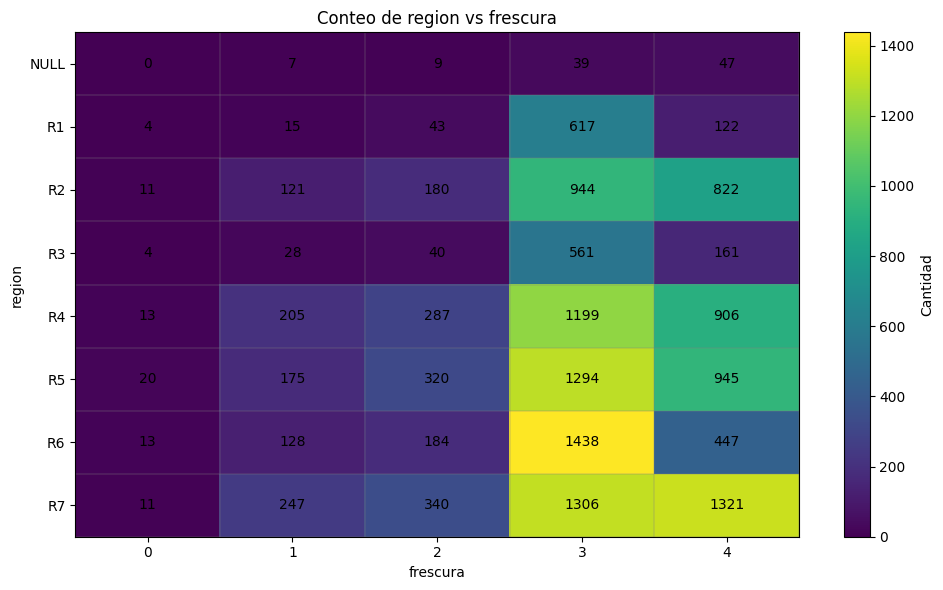

In [12]:
from pyspark.sql import functions as F
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
df_plot = (
    df_filtrado.groupBy("region", "frescura")
    .count()
)

pdf = df_plot.toPandas()

pdf["frescura"] = pdf["frescura"].fillna("NULL").astype(str)
pdf["region"] = pdf["region"].fillna("NULL").astype(str)

tabla = pdf.pivot(index="region", columns="frescura", values="count").fillna(0)
tabla = tabla.sort_index()
tabla = tabla.reindex(sorted(tabla.columns, key=lambda x: str(x)), axis=1)

fig, ax = plt.subplots(figsize=(10, 6))

im = ax.imshow(tabla.values, aspect="auto")

ax.set_xticks(np.arange(-.5, len(tabla.columns), 1), minor=True)
ax.set_yticks(np.arange(-.5, len(tabla.index), 1), minor=True)
ax.grid(which="minor", color="gray", linestyle='-', linewidth=0.3)
ax.tick_params(which="minor", bottom=False, left=False)

ax.set_title("Conteo de region vs frescura")
ax.set_xlabel("frescura")
ax.set_ylabel("region")

ax.set_xticks(np.arange(len(tabla.columns)))
ax.set_xticklabels(tabla.columns)
ax.set_yticks(np.arange(len(tabla.index)))
ax.set_yticklabels(tabla.index)

# mostrar etiquetas dentro de cada celda
for i in range(tabla.shape[0]):
    for j in range(tabla.shape[1]):
        ax.text(j, i, int(tabla.iloc[i, j]), ha="center", va="center")

plt.colorbar(im, ax=ax, label="Cantidad")
plt.tight_layout()
plt.show()

In [56]:
spark.stop()

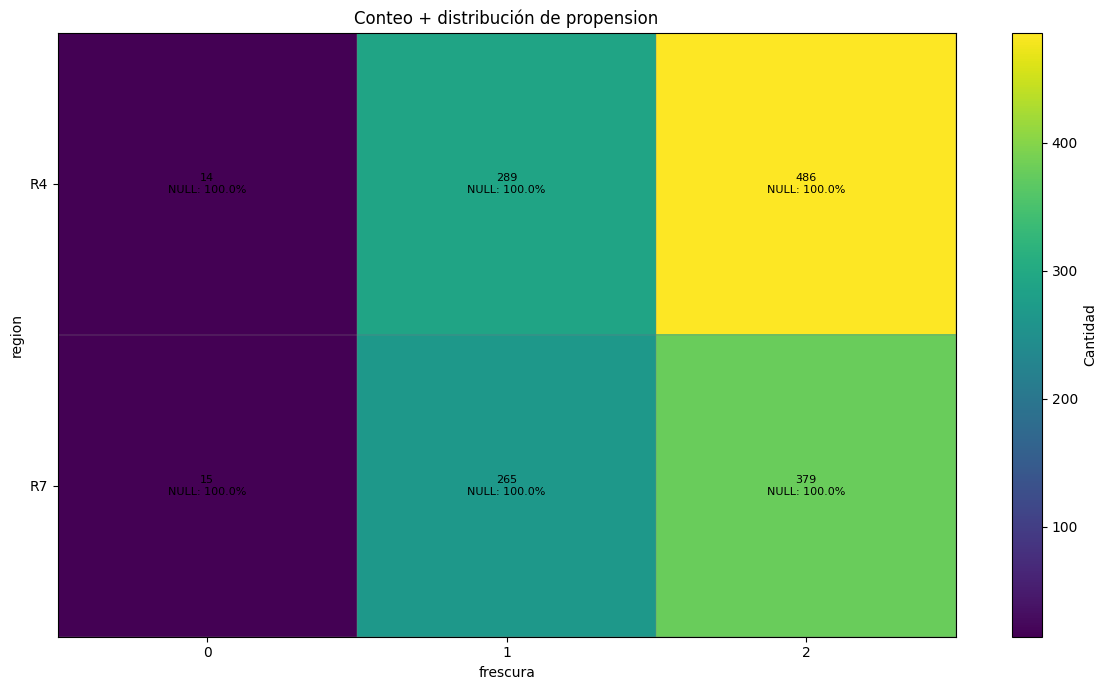

In [15]:
from pyspark.sql import functions as F
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# =====================================================
# 1) AGRUPAR POR 3 VARIABLES
# =====================================================
df_plot = (
    df_filtrado
    .groupBy(
        "region",
        "frescura",
        "propension"
    )
    .count()
)

pdf = df_plot.toPandas()

pdf["region"] = pdf["region"].fillna("NULL").astype(str)
pdf["frescura"] = pdf["frescura"].fillna("NULL").astype(str)
pdf["propension"] = pdf["propension"].fillna("NULL").astype(str)

# =====================================================
# 2) TOTAL POR PRODUCTO + PROPENSION
# =====================================================
pdf["total_celda"] = pdf.groupby(
    ["region", "frescura"]
)["count"].transform("sum")

pdf["pct"] = pdf["count"] / pdf["total_celda"] * 100

# =====================================================
# 3) TABLA DE VOLUMEN TOTAL
# =====================================================
tabla = pdf.pivot_table(
    index="region",
    columns="frescura",
    values="total_celda",
    aggfunc="max"
).fillna(0)

tabla = tabla.sort_index()
tabla = tabla.reindex(sorted(tabla.columns, key=lambda x: str(x)), axis=1)

# =====================================================
# 4) GRAFICAR
# =====================================================
fig, ax = plt.subplots(figsize=(12, 7))

im = ax.imshow(tabla.values, aspect="auto")

ax.set_title("Conteo + distribución de propension")
ax.set_xlabel("frescura")
ax.set_ylabel("region")

ax.set_xticks(np.arange(len(tabla.columns)))
ax.set_xticklabels(tabla.columns)

ax.set_yticks(np.arange(len(tabla.index)))
ax.set_yticklabels(tabla.index)

# grilla
ax.set_xticks(np.arange(-.5, len(tabla.columns), 1), minor=True)
ax.set_yticks(np.arange(-.5, len(tabla.index), 1), minor=True)
ax.grid(which="minor", color="gray", linestyle='-', linewidth=0.3)
ax.tick_params(which="minor", bottom=False, left=False)

# =====================================================
# 5) TEXTO DENTRO DE CADA CELDA
# =====================================================
for i, producto in enumerate(tabla.index):
    for j, propension in enumerate(tabla.columns):

        total = int(tabla.loc[producto, propension])

        subset = pdf[
            (pdf["region"] == producto) &
            (pdf["frescura"] == propension)
        ]

        texto_estados = "\n".join(
            subset.apply(
                lambda x: f"{x['propension']}: {x['pct']:.1f}%",
                axis=1
            )
        )

        texto = f"{total}\n{texto_estados}"

        ax.text(
            j, i,
            texto,
            ha="center",
            va="center",
            fontsize=8
        )

plt.colorbar(im, ax=ax, label="Cantidad")
plt.tight_layout()
plt.show()

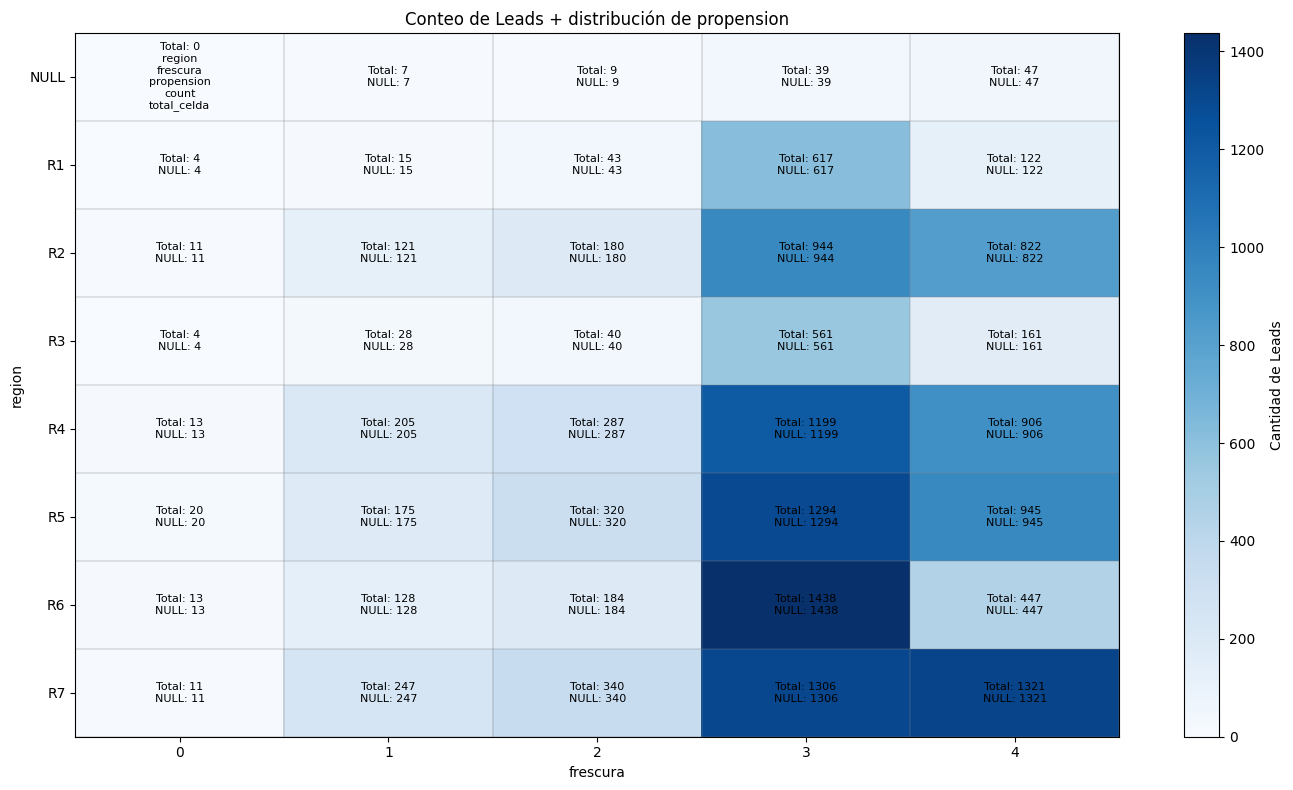

In [11]:
from pyspark.sql import functions as F
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# =====================================================
# 1) AGRUPAR POR 3 VARIABLES
# =====================================================
df_plot = (
    df_filtrado
    .groupBy(
        "region",
        "frescura",
        "propension"
    )
    .count()
)

pdf = df_plot.toPandas()

# Manejo de nulos
pdf["region"] = pdf["region"].fillna("NULL").astype(str)
pdf["frescura"] = pdf["frescura"].fillna("NULL").astype(str)
pdf["propension"] = pdf["propension"].fillna("NULL").astype(str)

# =====================================================
# 2) TOTAL POR REGION + FRESCURA
# =====================================================
pdf["total_celda"] = pdf.groupby(
    ["region", "frescura"]
)["count"].transform("sum")

# =====================================================
# 3) TABLA PARA HEATMAP
# =====================================================
tabla = pdf.pivot_table(
    index="region",
    columns="frescura",
    values="total_celda",
    aggfunc="max"
).fillna(0)

tabla = tabla.sort_index()
tabla = tabla.reindex(
    sorted(tabla.columns, key=lambda x: str(x)),
    axis=1
)

# =====================================================
# 4) GRAFICAR
# =====================================================
fig, ax = plt.subplots(figsize=(14, 8))

im = ax.imshow(
    tabla.values,
    aspect="auto",
    cmap="Blues"
)

ax.set_title("Conteo de Leads + distribución de propension")
ax.set_xlabel("frescura")
ax.set_ylabel("region")

ax.set_xticks(np.arange(len(tabla.columns)))
ax.set_xticklabels(tabla.columns)

ax.set_yticks(np.arange(len(tabla.index)))
ax.set_yticklabels(tabla.index)

# =====================================================
# 5) GRID
# =====================================================
ax.set_xticks(
    np.arange(-.5, len(tabla.columns), 1),
    minor=True
)

ax.set_yticks(
    np.arange(-.5, len(tabla.index), 1),
    minor=True
)

ax.grid(
    which="minor",
    color="gray",
    linestyle="-",
    linewidth=0.3
)

ax.tick_params(
    which="minor",
    bottom=False,
    left=False
)

# =====================================================
# 6) TEXTO DENTRO DE CADA CELDA
# =====================================================
for i, region in enumerate(tabla.index):

    for j, frescura in enumerate(tabla.columns):

        total = int(tabla.loc[region, frescura])

        subset = pdf[
            (pdf["region"] == region) &
            (pdf["frescura"] == frescura)
        ]

        # Texto por propension mostrando cantidad de leads
        texto_propension = "\n".join(
            subset.sort_values("propension").apply(
                lambda x: f"{x['propension']}: {int(x['count'])}",
                axis=1
            )
        )

        texto = f"Total: {total}\n{texto_propension}"

        ax.text(
            j,
            i,
            texto,
            ha="center",
            va="center",
            fontsize=8,
            color="black"
        )

# =====================================================
# 7) COLORBAR
# =====================================================
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Cantidad de Leads")

plt.tight_layout()
plt.show()

In [ ]:
df_list.groupBy('frescura') \
    .count() \
    .orderBy('count', ascending=False) \
    .show(30, truncate=False)

+--------+-----+
|frescura|count|
+--------+-----+
|4       |8251 |
|3       |2839 |
|2       |1607 |
|1       |1231 |
+--------+-----+



In [21]:
df_filtrado.groupBy('mejor15_descripcion_cli') \
    .count() \
    .orderBy('count', ascending=False) \
    .show(30, truncate=False)

+-------------------------------------------------+-----+
|mejor15_descripcion_cli                          |count|
+-------------------------------------------------+-----+
|DISCADOR                                         |16601|
|NO NECESITA UN PRÉSTAMO EN EL MES EN CURSO       |2110 |
|CORTA LLAMADA                                    |1927 |
|BRINDARÁ INFORMACIÓN A TITULAR                   |447  |
|DERIVA A CASILLA DE VOZ                          |299  |
|NO BRINDARÁ INFORMACIÓN A TITULAR                |267  |
|NO CONTESTAN                                     |248  |
|NO NECESITA UN PRÉSTAMO EN LOS PRÓXIMOS DOS MESES|156  |
|YA OBTUVO UN PRÉSTAMO EN OTRA ENTIDAD            |107  |
|NULL                                             |97   |
|TELÉFONO APAGADO                                 |92   |
|ALFIN NO TIENE SUCURSAL CERCA                    |16   |
|NO CONOCE ALFIN BANCO                            |1    |
+-------------------------------------------------+-----+



In [31]:
from pyspark.sql import functions as F
from pyspark.sql.window import Window

w = Window.partitionBy('perfil','producto_externo',"frescura",'propension_credicash').orderBy(F.rand())

df_split = df_filtrado.withColumn("grupo_split", F.ntile(2).over(w))

df_parte_1 = df_split.filter(F.col("grupo_split") == 1).drop("grupo_split")
df_parte_2 = df_split.filter(F.col("grupo_split") == 2).drop("grupo_split")
# df_parte_3 = df_split.filter(F.col("grupo_split") == 3).drop("grupo_split")
# df_parte_4 = df_split.filter(F.col("grupo_split") == 4).drop("grupo_split")
# df_parte_5 = df_split.filter(F.col("grupo_split") == 5).drop("grupo_split")
# df_parte_6 = df_split.filter(F.col("grupo_split") == 6).drop("grupo_split")
# df_parte_7 = df_split.filter(F.col("grupo_split") == 7).drop("grupo_split")

print(
    df_parte_1.count(),
    df_parte_2.count()
    # df_parte_3.count(),
    # df_parte_4.count()
    # df_parte_5.count(),
    # df_parte_6.count(),
    # df_parte_7.count()
)

6656 6518


In [ ]:
['cabecera_carga', 'dni_cliente', 'contacto', 'cl_id', 'id_servicio', 'mejor_codigo_cli_dia', 'mejor15_codigo_telf', 'mejor15_codigo_cli', 'mejor_codigo_cli', 'tipo_telf', 'cod_attempt', 'q_intentos_telef', 'indice_tpo_telf', 'contacto_02', 'min_numero', 'oferta_max', 'oferta_electro', 'tasa_electro', 'plazo_electro', 'cme_electro', 'oferta_credicash', 'tasa_credicash', 'plazo_credicash', 'cme_credicash', 'perfil', 'plazo', 'tasa', 'cme_disponible', 'lote', 'proveedor', 'msi', 'flg_credicash', 'propension', 'campana', 'cl_carga', 'obs_fcc', 'semaforo', 'region', 'tienda_ir', 'situacion_laboral', 'score_telefono', 'marca_pd', 'grupo_segmento', 'producto_externo', 'propension_electro', 'propension_credicash', 'flg_cruce_recurrente', 'alta_demanda', 'demanda', 'prioridad', 'inicio', 'fin', 'producto_interno', 'flg_aahh', 'intensidad_max', 'frescura', 'seg_oferta', 'seg_oferta_credicash', 'seg_oferta_electro', 'seg_tasa_credicash', 'seg_tasa_electro', 'seg_cme_electro', 'seg_cme_credicash', 'duracion', 'ult_codigo_result', 'fecha_llamada', 'dni_ejecutvo', 'dni_unico', 'mejor_estado_tipi_cli', 'mejor_sub_descripcion', 'mejor_descripcion_cli', 'mejor_peso_cli', 'mejor15_estado_tipi_cli', 'mejor15_descripcion_cli', 'mejor15_sub_descripcion_cli', 'mejor15_peso_cli', 'mejor15_estado_tipi_telf', 'mejor15_descripcion_telf', 'mejor15_sub_descripcion_telf', 'mejor15_peso_telf', 'mejor_estado_tipi_cli_dia', 'mejor_descripcion_cli_dia', 'mejor_sub_descripcion_cli_dia', 'mejor_peso_cli_dia', 'retiro']prope
v

In [19]:
from pyspark.sql.window import Window

window_agencia = Window.partitionBy('region',"tienda_ir")

df_final = df_filtrado.withColumn(
    "cnt_agencia",
    F.count("*").over(window_agencia)
)
df_final=df_final.filter(
    F.col("cnt_agencia") > 100
)
print(df_final.count())


4122


In [ ]:
import os

def exportar_excel(df, columnas, ruta_base, nombre_archivo):
    """
    df: DataFrame de PySpark
    columnas: lista de columnas a seleccionar
    ruta_base: carpeta donde guardar
    nombre_archivo: nombre del archivo (sin extensión opcional)
    """
    
    df_filtrado = df.select(*columnas).toPandas()
    
    ruta = os.path.join(ruta_base, f"{nombre_archivo}.xlsx")
    
    df_filtrado.to_excel(ruta, index=False)
    
    print(f"Archivo guardado en: {ruta}")

In [ ]:
['dni_cliente', 'cabecera_carga', 'contacto', 'cl_id', 'id_servicio', 'mejor_codigo_cli_dia', 'mejor15_codigo_telf', 'mejor15_codigo_cli', 'mejor_codigo_cli', 'tipo_telf', 'cod_attempt', 'q_intentos_telef', 'indice_tpo_telf', 'contacto_02', 'min_numero', 'oferta_max', 'oferta_electro', 'tasa_electro', 'plazo_electro', 'cme_electro', 'oferta_credicash', 'tasa_credicash', 'plazo_credicash', 'cme_credicash', 'perfil', 'plazo', 'tasa', 'cme_disponible', 'lote', 'proveedor', 'msi', 'flg_credicash', 'propension', 'campana', 'cl_carga', 'obs_fcc', 'semaforo', 'region', 'tienda_ir', 'situacion_laboral', 'score_telefono', 'marca_pd', 'grupo_segmento', 'producto_externo', 'propension_electro', 'propension_credicash', 'flg_cruce_recurrente', 'alta_demanda', 'demanda', 'prioridad', 'inicio', 'fin', 'producto_interno', 'flg_aahh', 'intensidad_max', 'frescura', 'seg_oferta', 'seg_oferta_credicash', 'seg_oferta_electro', 'seg_tasa_credicash', 'seg_tasa_electro', 'seg_cme_electro', 'seg_cme_credicash', 'duracion', 'ult_codigo_result', 'fecha_llamada', 'dni_ejecutivo', 'dni_unico', 'mejor_estado_tipi_cli', 'mejor_sub_descripcion', 'mejor_descripcion_cli', 'mejor_peso_cli', 'mejor15_estado_tipi_cli', 'mejor15_descripcion_cli', 'mejor15_sub_descripcion_cli', 'mejor15_peso_cli', 'mejor15_estado_tipi_telf', 'mejor15_descripcion_telf', 'mejor15_sub_descripcion_telf', 'mejor15_peso_telf', 'mejor_estado_tipi_cli_dia', 'mejor_descripcion_cli_dia', 'mejor_sub_descripcion_cli_dia', 'mejor_peso_cli_dia', 'retiro', 'lote_01', 'id', 'NUMERO_DOCUMENTO']

['dni_cliente', 'cabecera_carga', 'contacto', 'cl_id', 'id_servicio', 'mejor_codigo_cli_dia', 'mejor15_codigo_telf', 'mejor15_codigo_cli', 'mejor_codigo_cli', 'tipo_telf', 'cod_attempt', 'q_intentos_telef', 'indice_tpo_telf', 'contacto_02', 'min_numero', 'oferta_max', 'oferta_electro', 'tasa_electro', 'plazo_electro', 'cme_electro', 'oferta_credicash', 'tasa_credicash', 'plazo_credicash', 'cme_credicash', 'perfil', 'plazo', 'tasa', 'cme_disponible', 'lote', 'proveedor', 'msi', 'flg_credicash', 'propension', 'campana', 'cl_carga', 'obs_fcc', 'semaforo', 'region', 'tienda_ir', 'situacion_laboral', 'score_telefono', 'marca_pd', 'grupo_segmento', 'producto_externo', 'propension_electro', 'propension_credicash', 'flg_cruce_recurrente', 'alta_demanda', 'demanda', 'prioridad', 'inicio', 'fin', 'producto_interno', 'flg_aahh', 'intensidad_max', 'frescura', 'seg_oferta', 'seg_oferta_credicash', 'seg_oferta_electro', 'seg_tasa_credicash', 'seg_tasa_electro', 'seg_cme_electro', 'seg_cme_credicash'

In [35]:
df_list_filtrada = df_filtrado.select(
    'cabecera_carga','tienda_ir','region','semaforo'
).toPandas()
ruta_archivo = os.path.join(ruta_csv, 'id55_crewdi.xlsx')
df_list_filtrada.to_excel(ruta_archivo, index=False)

In [ ]:
['dni_cliente', 'cabecera_carga', 'contacto', 'cl_id', 'id_servicio', 'mejor_codigo_cli_dia', 'mejor15_codigo_telf', 'mejor15_codigo_cli', 'mejor_codigo_cli', 'tipo_telf', 'cod_attempt', 'q_intentos_telef', 'indice_tpo_telf', 'contacto_02', 'min_numero', 'oferta_max', 'oferta_electro', 'tasa_electro', 'plazo_electro', 'cme_electro', 'oferta_credicash', 'tasa_credicash', 'plazo_credicash', 'cme_credicash', 'perfil', 'plazo', 'tasa', 'cme_disponible', 'lote', 'proveedor', 'msi', 'flg_credicash', 'propension', 'campana', 'cl_carga', 'obs_fcc', 'semaforo', 'region', 'tienda_ir', 'situacion_laboral', 'score_telefono', 'marca_pd', 'grupo_segmento', 'producto_externo', 'propension_electro', 'propension_credicash', 'flg_cruce_recurrente', 'alta_demanda', 'demanda', 'prioridad', 'inicio', 'fin', 'producto_interno', 'flg_aahh', 'intensidad_max', 'frescura', 'seg_oferta', 'seg_oferta_credicash', 'seg_oferta_electro', 'seg_tasa_credicash', 'seg_tasa_electro', 'seg_cme_electro', 'seg_cme_credicash', 'duracion', 'ult_codigo_result', 'fecha_llamada', 'dni_ejecutivo', 'dni_unico', 'mejor_estado_tipi_cli', 'mejor_sub_descripcion', 'mejor_descripcion_cli', 'mejor_peso_cli', 'mejor15_estado_tipi_cli', 'mejor15_descripcion_cli', 'mejor15_sub_descripcion_cli', 'mejor15_peso_cli', 'mejor15_estado_tipi_telf', 'mejor15_descripcion_telf', 'mejor15_sub_descripcion_telf', 'mejor15_peso_telf', 'mejor_estado_tipi_cli_dia', 'mejor_descripcion_cli_dia', 'mejor_sub_descripcion_cli_dia', 'mejor_peso_cli_dia', 'retiro', 'lote_01']

['dni_cliente', 'cabecera_carga', 'contacto', 'cl_id', 'id_servicio', 'mejor_codigo_cli_dia', 'mejor15_codigo_telf', 'mejor15_codigo_cli', 'mejor_codigo_cli', 'tipo_telf', 'cod_attempt', 'q_intentos_telef', 'indice_tpo_telf', 'contacto_02', 'min_numero', 'oferta_max', 'oferta_electro', 'tasa_electro', 'plazo_electro', 'cme_electro', 'oferta_credicash', 'tasa_credicash', 'plazo_credicash', 'cme_credicash', 'perfil', 'plazo', 'tasa', 'cme_disponible', 'lote', 'proveedor', 'msi', 'flg_credicash', 'propension', 'campana', 'cl_carga', 'obs_fcc', 'semaforo', 'region', 'tienda_ir', 'situacion_laboral', 'score_telefono', 'marca_pd', 'grupo_segmento', 'producto_externo', 'propension_electro', 'propension_credicash', 'flg_cruce_recurrente', 'alta_demanda', 'demanda', 'prioridad', 'inicio', 'fin', 'producto_interno', 'flg_aahh', 'intensidad_max', 'frescura', 'seg_oferta', 'seg_oferta_credicash', 'seg_oferta_electro', 'seg_tasa_credicash', 'seg_tasa_electro', 'seg_cme_electro', 'seg_cme_credicash'

In [15]:
producto_externo=[
 'CREDICASH',
 'CREDICASH R / ELECTRO',
 ]
# producto_externo=['CREDICASH R / ELECTRO MSI', 'CREDICASH R / ELECTRO', 'CREDICASH R', 'CREDICASH / ELECTRO', 'CREDICASH', 'CREDICASH / ELECTRO MSI']


['CREDICASH']

In [20]:
df_list_filtrada = df_filtrado.select(
    'cabecera_carga',
).toPandas()
ruta_archivo = os.path.join(ruta_csv, 'cregfhxxx__1.csv')

import csv

df_list_filtrada.to_csv(
    ruta_archivo,
    index=False,
    sep=",",
    header=False,
    encoding="latin-1", 
    lineterminator="\r\n"
)


df_list_filtrada.count()

cabecera_carga    7873
dtype: int64

In [ ]:
producto_externo=[
    'CREDICASH R / ELECTRO MSI',
 'CREDICASH R / ELECTRO',
 'CREDICASH',
 ]



In [15]:
df_filtrado.groupBy('producto_externo') \
    .count() \
    .orderBy('count', ascending=False) \
    .show(30, truncate=False)

+-----------------------+-----+
|producto_externo       |count|
+-----------------------+-----+
|CREDICASH / ELECTRO    |5077 |
|CREDICASH / ELECTRO MSI|3908 |
|CREDICASH              |889  |
+-----------------------+-----+



In [40]:
df_filtrado.groupBy('producto_externo') \
    .count() \
    .orderBy('producto_externo') \
    .show(30, truncate=False)

+-------------------------+-----+
|producto_externo         |count|
+-------------------------+-----+
|CREDICASH / ELECTRO      |5416 |
|CREDICASH / ELECTRO MSI  |2079 |
|CREDICASH R / ELECTRO    |156  |
|CREDICASH R / ELECTRO MSI|27   |
+-------------------------+-----+



In [ ]:
producto_externo=[
    'CREDICASH R / ELECTRO MSI',
 'CREDICASH R / ELECTRO',
 'CREDICASH R',
 'CREDICASH / ELECTRO',
 'CREDICASH',
 ]


In [ ]:

df_dni = df_filtrado.toPandas()

import os

ruta_archivo = os.path.join(ruta_csv, 'credicash_.xlsx')

df_dni.to_excel(ruta_archivo, index=False)

In [11]:
print([row['perfil' ] for row in df_list.select('perfil').distinct().collect()])


['O1', 'D1', 'O2', 'O3', 'D2', 'D0']


['LLAMADA ELIMINADA POR ERROR EN RED (AUTO)', 'AUTODIAL NO RESPONDE (AUTO)', 'OCUPADO (AUTO)', 'GESTION EN PROCESO (AUTO)', 'MENSAJE EN CASILLA DE VOZ (AUTO)', 'AGENTE NO DISPONIBLE (AUTO)']


In [ ]:

exportar_lista(df_filtrado,'tc_cenco_2026033014.xlsx','linea_cencosud')

In [50]:
cantidad_leads=df_filtrado.count()

In [56]:
info_list=f"""
Se tienen {cantidad_leads} leads
Prioridad : {quintil}
maximo de intentos por num telef: {q_intentos_telef}
flg_ex_cliente :{flg_ex_cliente}
{segmento}
{first_name}

"""

print(info_list)


Se tienen 2814 leads
Prioridad : ['1', '2']
maximo de intentos por num telef: 40
flg_ex_cliente :['NUEVO']
['TC2', 'TC1']
['SEGMENTO BONUS', 'SEGMENTO EXCLUSIVO']




In [79]:
exportar_lista(df_filtrado,'tc_cencor_202603310847.xlsx','linea_cencosud')

['LLAMADA ELIMINADA POR ERROR EN RED (AUTO)', 'VOLVER A LLAMAR', 'CLIENTE CUELGA ANTES DE ESCUCHAR OFERTA', 'NO UTILIZA (TARJETAS - PRESTAMOS)', 'AUTODIAL NO RESPONDE (AUTO)', 'OFERTA DE TASA MUY ALTA', 'OFERTA DE LINEA MUY BAJA', 'NO DESEA PAGAR MEMBRESIA', 'NO SE CONCRETO LLAMADA (CASILLA DE VOZ - APAGADO)', 'VOLVER A LLAMAR (TERCERO RELACIONADO)', 'ZONA FUERA DE COBERTURA', 'NO VOLVER A LLAMAR NUNCA MAS', 'VOLVER A LLAMAR - call', 'TELEFONO OCUPADO / NO CONTESTAN', 'OCUPADO (AUTO)', 'NO SE ASIGNO RESULTADO A LA LLAMADA (AUTO)', 'NO DESEA –NO ESPECIFICA MOTIVO', 'TELEFONO EQUIVOCADO', 'NUMERO DESCONECTADO (AUTO)', 'MENSAJE EN CASILLA DE VOZ (AUTO)', 'CLIENTE FALLECIO', 'CLIENTE ACEPTA PRODUCTO', 'TELEFONO FUERA DE SERVICIO / NO EXISTE', 'DESEA IR A AGENCIA', 'CLIENTE DESEA OTRO PRODUCTO', 'AGENTE NO DISPONIBLE (AUTO)', None]


In [ ]:
import os

ruta_archivo = os.path.join(ruta_csv, 'ivr_202603271706.xlsx')

df_dni.to_excel(ruta_archivo, index=False)

In [142]:

df_dni = df_filtrado.toPandas()


In [73]:
los pu pm los qu epodemos usar


SyntaxError: invalid syntax (2290498890.py, line 1)

In [12]:

nombre_archivo_xlsx='SAE_202603251722.xlsx'
columna_ref='linea_sae'
exportar_lista(df_filtrado,nombre_archivo_xlsx,columna_ref)


In [ ]:
fecha_mes_base='2026-03-01'
t_maestra='Base_Maestra_Cencosud_PPFF'
t_name_vigente='Base_Maestra_Cencosud_PPFF_vigente'
t_mumeros='tNumeroCenco_Sae'
cols_drop=[ 'FRESCURA_TARGET', 'REP1', 'REP2', 'REP3','FLAT2']


In [97]:
df_filtrado = df_filtrado.select(
    'vendor_lead_code', 'phone_number', 'first_name',
    'last_name', 'address1', 'address2', 'address3',
    'city', 'province', 'email', 'security_phrase', 'comments'
)
df_dni = df_filtrado.toPandas()

In [ ]:
import matplotlib.pyplot as plt

df_dni['email'].value_counts().plot(kind='bar')

plt.title('Top departamentos (email)')
plt.xlabel('Departamento')
plt.ylabel('Cantidad')
plt.xticks(rotation=45)
plt.show()

In [8]:
df_list.select('retiro_01').filter(col('retiro_01')==0).count()

2266

In [13]:
# print([row['first_name'] for row in df_list.select('first_name').distinct().collect()])
# print([row['title'] for row in df_list.select('title').distinct().collect()])
# print([row['tip_prioridad'] for row in df_list.select('tip_prioridad').distinct().collect()])
# print([row['email'] for row in df_list.select('email').distinct().collect()])
# print([row['prioridada'] for row in df_list.select('prioridada').distinct().collect()])
print([row['mejor15_descripcion_telf' ] for row in df_list.select('mejor15_descripcion_telf').distinct().collect()])
# print(df_list.columns)


['PERSONA FALLECIDA', 'VOLVER A LLAMAR', 'LO VA A PENSAR', 'DESEA ELECTRO', 'NEGOCIO EN ZONA NO COBERTURADA', 'TITULAR CONTAGIADO CON COVID - 19', 'CREDITO CONCRETADO', 'MENSAJES CON TERCEROS - HIJOS', 'NO DESEA SER CONTACTADO / MANIFIESTA SU RECHAZO', 'NO NECESITA / NO DESEA', 'TELEFONO APAGADO', 'NUMERO EQUIVOCADO', 'ESTA ENDEUDADO', 'MENSAJES CON TERCEROS - ESPOSA', 'OTROS', 'NO CONTESTA ', 'TITULAR NO CALIFICA- GIRO RESTRINGIDO9', 'CLIENTE RECHAZADO', 'MENSAJES CON TERCEROS - OTROS', 'NO BRINDA CONSENTIMIENTO', 'CASA EN ZONA NO COBERTURADA', 'SI QUIERE', 'CLIENTE DE VIAJE', 'TELEFONO FUERA DE SERVICIO/SUSPENDIDO', 'CONFIRMAR CITA', 'INTERESES ELEVADOS', 'NUMERO NO EXISTE', 'TITULAR NO CALIFICA - DESEMPLEO', 'MENSAJES DE TEXTO', 'TONO OCUPADO', 'SOLICITA SER RETIRADO', 'IVR - NO CONFIRMA', 'MALA EXPERIENCIA (TDA/FNC)', 'DESEA MAS MONTO', 'NO QUIERE', None]
